In [73]:
import xarray as xr
import cmcrameri.cm as cmc
import matplotlib.pyplot as plt
import numpy as np


import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [74]:
ds = xr.open_zarr('./neuralgcm_atmospheric_river_predictions.zarr', chunks='auto', consolidated=False)
print(ds)

<xarray.Dataset> Size: 85MB
Dimensions:                              (time: 5, model: 2, level: 37,
                                          longitude: 128, latitude: 64)
Coordinates:
  * time                                 (time) int64 40B 0 24 48 72 96
  * model                                (model) object 16B 'ERA5' 'NeuralGCM'
  * level                                (level) int64 296B 1 2 3 ... 975 1000
  * longitude                            (longitude) float64 1kB 0.0 ... 357.2
  * latitude                             (latitude) float64 512B -87.86 ... 8...
Data variables:
    specific_cloud_liquid_water_content  (model, time, level, longitude, latitude) float32 12MB dask.array<chunksize=(1, 3, 19, 64, 32), meta=np.ndarray>
    specific_humidity                    (model, time, level, longitude, latitude) float32 12MB dask.array<chunksize=(1, 3, 19, 64, 32), meta=np.ndarray>
    u_component_of_wind                  (model, time, level, longitude, latitude) float32 12MB dask.

/home/sungche/.conda/envs/neuralgcm/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [75]:
print(f'LAT: {ds.latitude.values}\n')
print(f'LON: {ds.longitude.values}')

LAT: [-87.86379884 -85.09652699 -82.31291295 -79.52560657 -76.73689968
 -73.94751515 -71.15775201 -68.36775611 -65.57760701 -62.7873518
 -59.99702011 -57.20663153 -54.41619953 -51.62573367 -48.83524097
 -46.04472663 -43.25419467 -40.46364818 -37.67308963 -34.88252099
 -32.09194388 -29.30135962 -26.51076933 -23.72017393 -20.92957425
 -18.13897099 -15.34836476 -12.55775612  -9.76714556  -6.97653355
  -4.18592053  -1.39530691   1.39530691   4.18592053   6.97653355
   9.76714556  12.55775612  15.34836476  18.13897099  20.92957425
  23.72017393  26.51076933  29.30135962  32.09194388  34.88252099
  37.67308963  40.46364818  43.25419467  46.04472663  48.83524097
  51.62573367  54.41619953  57.20663153  59.99702011  62.7873518
  65.57760701  68.36775611  71.15775201  73.94751515  76.73689968
  79.52560657  82.31291295  85.09652699  87.86379884]

LON: [  0.       2.8125   5.625    8.4375  11.25    14.0625  16.875   19.6875
  22.5     25.3125  28.125   30.9375  33.75    36.5625  39.375   42.1875

In [76]:
us_ds = ds.where(
    (ds.longitude >= 235) & (ds.longitude <= 294) &
    (ds.latitude >= 24) & (ds.latitude <= 50),
    drop=True
)


In [77]:
wc = ds.specific_cloud_liquid_water_content
temp = ds.temperature
g = ds.geopotential

# Model Predict Results

## Water Content 

In [78]:
PRESURE_LEVEL = 850

In [79]:
print(wc)

<xarray.DataArray 'specific_cloud_liquid_water_content' (model: 2, time: 5,
                                                         level: 37,
                                                         longitude: 128,
                                                         latitude: 64)> Size: 12MB
dask.array<open_dataset-specific_cloud_liquid_water_content, shape=(2, 5, 37, 128, 64), dtype=float32, chunksize=(1, 3, 19, 64, 32), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) int64 40B 0 24 48 72 96
  * model      (model) object 16B 'ERA5' 'NeuralGCM'
  * level      (level) int64 296B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * latitude   (latitude) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86


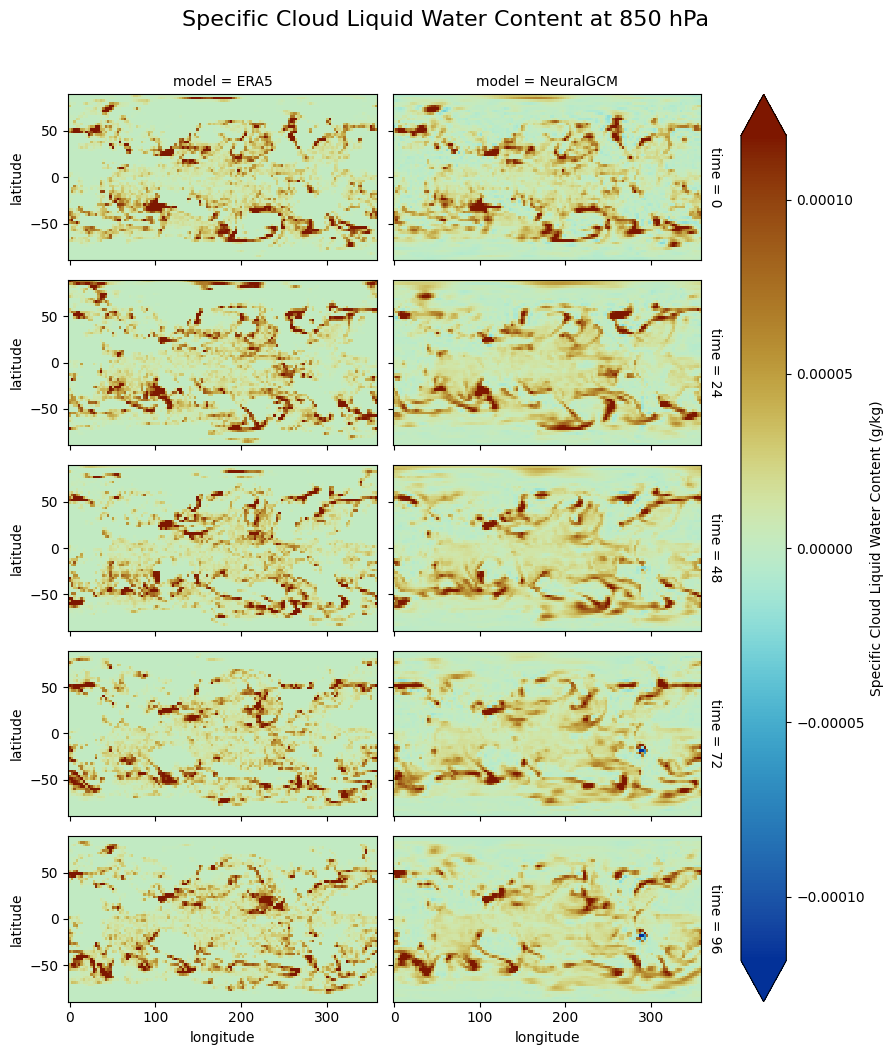

In [80]:
# Visualize ERA5 vs NeuralGCM trajectories
ds.specific_cloud_liquid_water_content.sel(level=PRESURE_LEVEL).plot(
    x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2,
    cmap=cmc.roma_r,  # 使用 _r 取得反向 colormap
    cbar_kwargs={'label': 'Specific Cloud Liquid Water Content (g/kg)'}
)

plt.suptitle(f'Specific Cloud Liquid Water Content at {PRESURE_LEVEL} hPa', fontsize=16, y=1.05)
plt.show()

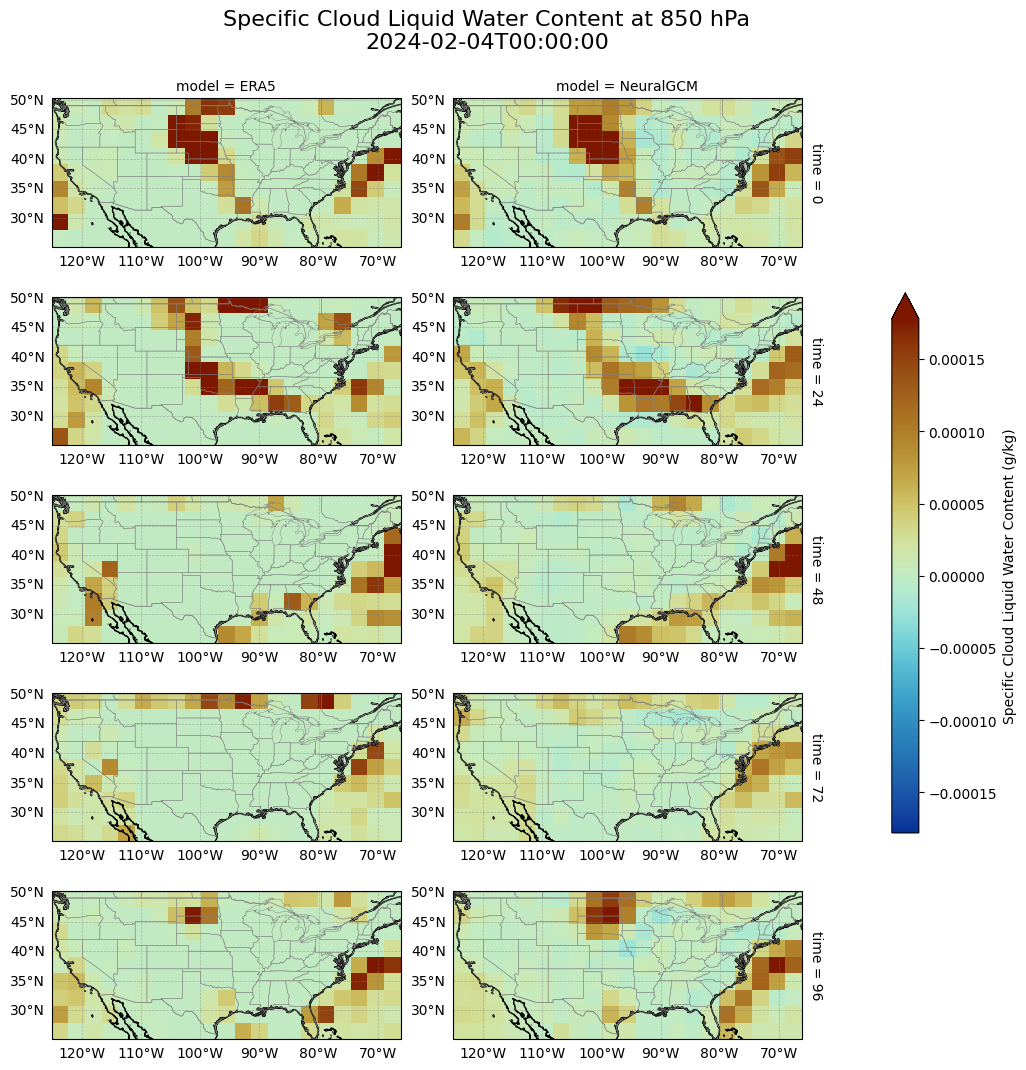

In [82]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Plot with xarray, get the FacetGrid object
g = us_ds.specific_cloud_liquid_water_content.sel(level=PRESURE_LEVEL).plot(
    x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2,
    cmap=cmc.roma_r,
    cbar_kwargs={'label': 'Specific Cloud Liquid Water Content (g/kg)'},
    subplot_kws={'projection': ccrs.PlateCarree()}  # Add this line for geographic plottings
)

for ax in g.axs.flat:
    ax.coastlines(resolution='10m', color='black', linewidth=1)
    ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
    ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xformatter = ccrs.cartopy.mpl.ticker.LongitudeFormatter()
    gl.yformatter = ccrs.cartopy.mpl.ticker.LatitudeFormatter()

plt.subplots_adjust(wspace=0.15, hspace=0.25, right=0.85)  # right 控制主圖區域寬度

# 調整 colorbar 位置
g.cbar.ax.set_position([0.95, 0.15, 0.03, 0.7])  # [left, bottom, width, height]，可依需求微調

time = '2024-02-04T00:00:00'
plt.suptitle(f'Specific Cloud Liquid Water Content at {PRESURE_LEVEL} hPa\n{time}', fontsize=16, y=1.05)
plt.show()


## Temperature

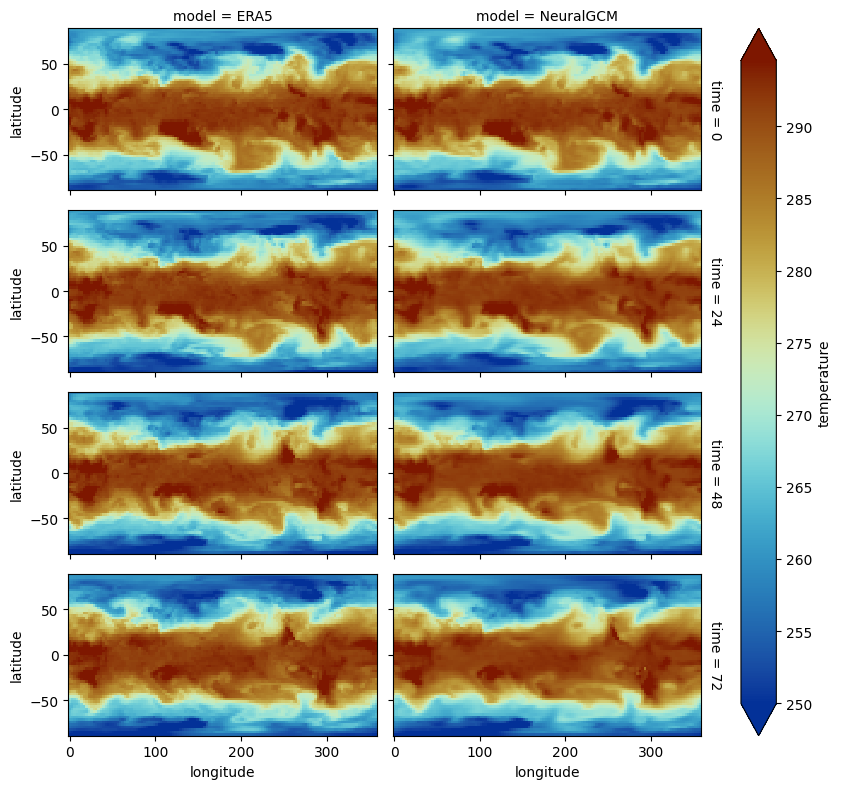

In [57]:
# Visualize ERA5 vs NeuralGCM trajectories
ds.temperature.sel(level=850).plot(
    x='longitude', 
    y='latitude', 
    row='time', 
    col='model', 
    robust=True, 
    aspect=2, 
    size=2,
    cmap=cmc.roma_r,
)

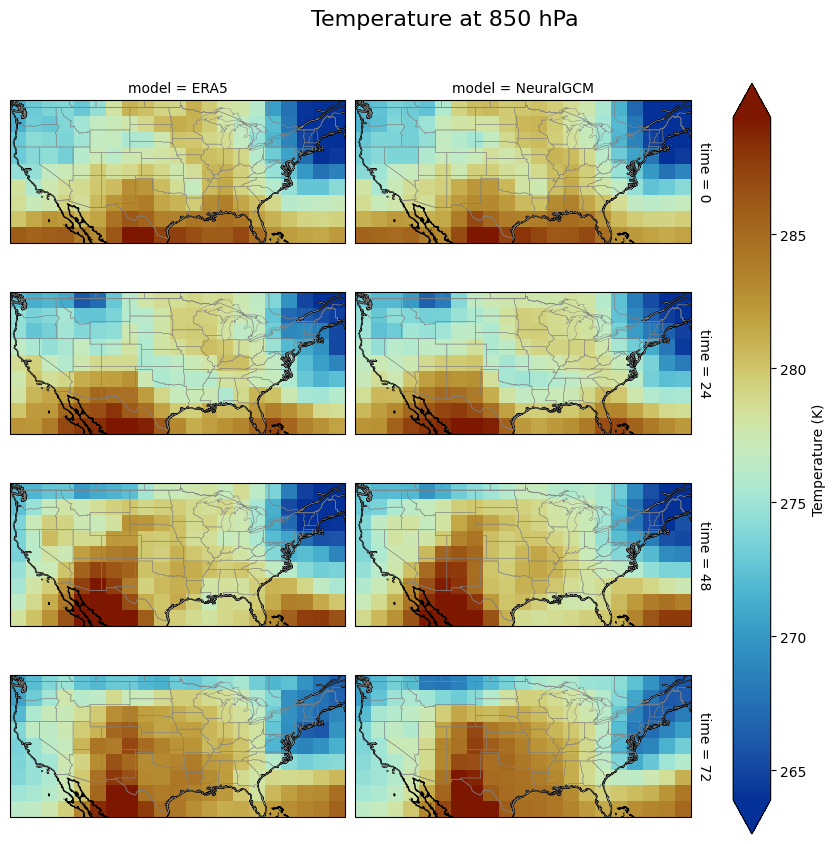

In [56]:
# Plot with xarray, get the FacetGrid object
g = us_ds.temperature.sel(level=PRESURE_LEVEL).plot(
    x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2,
    cmap=cmc.roma_r,
    cbar_kwargs={'label': 'Temperature (K)'},
    subplot_kws={'projection': ccrs.PlateCarree()}  # Add this line for geographic plotting
)

# Add coastlines and borders to each subplot
for ax in g.axs.flat:
    ax.coastlines(resolution='10m', color='black', linewidth=1)
    ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
    ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.3)  # US state boundaries

plt.suptitle(f'Temperature at {PRESURE_LEVEL} hPa', fontsize=16, y=1.05)
plt.show()


## Geopotential